In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.special import factorial
from scipy.stats import binned_statistic
from matplotlib.ticker import ScalarFormatter
import sys

In [2]:
sys.path.append(r"C:\Users\xylin\Documents\Researches\multiphonon-direct-detection\StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D
from StructureFactor1D import StructureFactor1D_NIndepDW

In [3]:
class StructureFactor1DCoherent(StructureFactor1D_NIndepDW):
    ######## Public ########

    def init_recursion(self): 
        self.sOrder = 1
        print(f'Processing n = {self.sOrder}...')
        self._s_diag_init()
        self._c_offdiag_init()

    def update_s_factor(self):
        '''
        Update the integrated diagonal s factor (both diagonal and off diagonal) using the recursive relation.
        '''
        self.sOrder += 1
        print(f'Processing n = {self.sOrder}...')
        # update diagonal term
        newOmega, newS = self._calc_s_diag_rec()
        self.currIntS_diag = self._integrate_s_diag(newOmega, newS)
        # update off diagonal term
        newOmega, newC = self._calc_c_offdiag_rec()
        self.currIntC_offdiag = self._integrate_c_offdiag(newOmega, newC)

    def get_binned_s_offdiag(self, xlist, delta_omega):
        # sum over c_ll' to get s factor
        mult = (self.nLattice - self.l_diff)*np.real(self.currIntC_offdiag)
        sfactor_sum = 2* (self.couplingConst**2) * np.sum(mult, axis=1)
        result = binned_statistic(self._DoS_x_list, sfactor_sum, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
        ylist = result.statistic/delta_omega
        return np.nan_to_num(ylist, nan=0.0) # cleaning up the nan

    ######## Helper ########

    def _c_offdiag_init(self,): # l' minus l
        '''
        Calculate the first c_ll' of the recursive relation. 
        currIntC_offdiag: 2d array with shape (# of nu, # of xi)
        '''
        DWfactor =  np.exp(- 2 * self.getDebyeWallerConst()) 
        offdiag_factor = np.exp(1j*(self.q_value*self.latticeConst-2*np.pi* self.nuList/self.nLattice)* self.l_diff) 
        c_values =  2 * np.pi / self.volume * DWfactor *  (self.q_value**2 /(2*self.mass*self.nLattice)) * offdiag_factor/ self.omegaList[:,np.newaxis]
        self.currIntC_offdiag = self._integrate_c_offdiag(self.omegaList, c_values)


    def _integrate_c_offdiag(self,allowed_omegas, c_offdiag):
        '''
        Get the integrated version of c_ll'
        '''
        result = binned_statistic(allowed_omegas, c_offdiag.T, statistic="sum",bins=self._DoS_nBins, range=(self._DoS_min_omega, self._DoS_max_omega))
        return result.statistic.T

    def _calc_c_offdiag_rec(self,):
        exp_factor = np.exp(-2j*np.pi*self.nuList*self.l_diff/self.nLattice)
        rec_factor = exp_factor/self.omegaList[:, np.newaxis]
        newIntC = (self.q_value**2 /(2*self.mass*self.nLattice))/self.sOrder * rec_factor[:, np.newaxis, :]*self.currIntC_offdiag
        newOmega = self._DoS_x_list[:, np.newaxis] + self.omegaList 
        return newOmega.T.reshape(-1,), newIntC.reshape(-1,self.l_diff.shape[0])
    


Processing n = 1...
Plotting n = 1...
Processing n = 2...
Plotting n = 2...
Processing n = 3...
Plotting n = 3...
Processing n = 4...
Plotting n = 4...
Processing n = 5...
Plotting n = 5...
Processing n = 6...
Plotting n = 6...
Processing n = 7...
Plotting n = 7...
Processing n = 8...
Plotting n = 8...
Processing n = 9...
Plotting n = 9...
Processing n = 10...
Plotting n = 10...


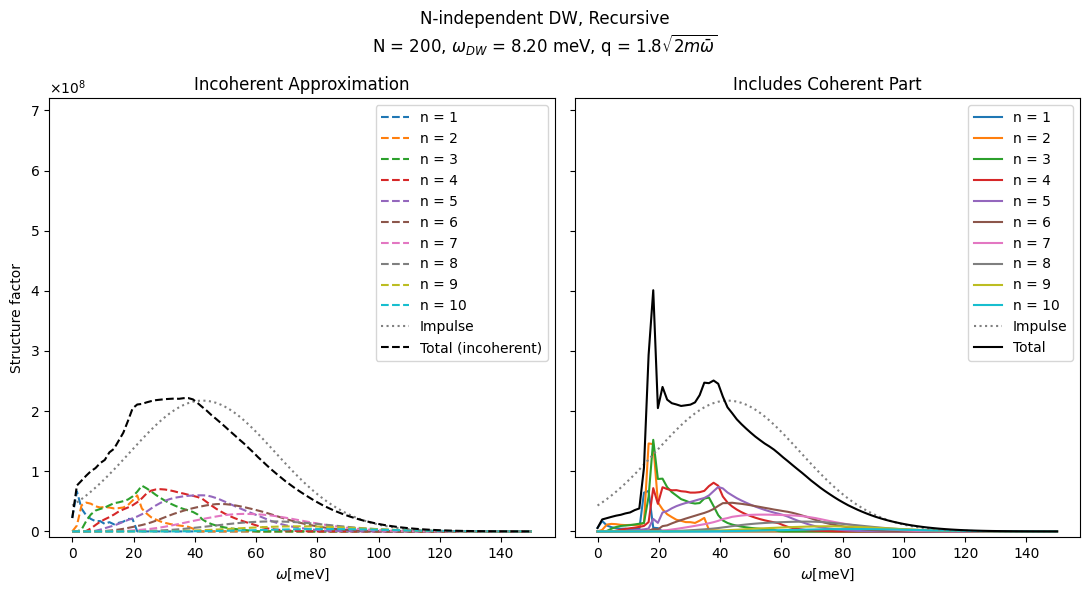

In [6]:
omega_dw = 8.2e-6
multplier = 1.8
q_value  = multplier*np.sqrt(2*26161e3*13.13e-6) # uses averaged omega (not inverse of averaged inverse)


nLattice = 200
test = StructureFactor1DCoherent(nLattice = nLattice,q_value=q_value, couplingConst=28,)
# color = ['r', 'g', 'b', 'y', 'c', 'tab:blue', 'tab:red', 'tab:yellow', "tab:brown", 'tab:purple']
max_omega = 150*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega,100, retstep=True) 
nPhonon = 10


# impulse approx
deltasq = q_value**2 * 13.13e-6/(2*test.mass)
ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

sum_diag = np.zeros(xlist.shape)
sum_offdiag = np.zeros(xlist.shape)
fig, ax = plt.subplots(figsize=(11,6), ncols=2, sharey=True)
test.setup_DoS(max_omega, nBins=1000)
test.init_recursion()
# get the binned s factor of order 1
s_diag = test.get_binned_s_diag(xlist, delta_omega)
s_offdiag = test.get_binned_s_offdiag(xlist, delta_omega)
# update the sum of s factor
sum_diag += s_diag 
sum_offdiag += s_offdiag
# plot the current s factor
print(f'Plotting n = 1...')
ax[0].plot(xlist*1e6, s_diag,label=f'n = 1',  linestyle='--') 
ax[1].plot(xlist*1e6, s_diag+s_offdiag,label=f'n = 1',) 
for i in range(2,nPhonon+1):
    test.update_s_factor()
    # get the binned s factor of order i
    s_diag = test.get_binned_s_diag(xlist, delta_omega)
    s_offdiag = test.get_binned_s_offdiag(xlist, delta_omega)
    # update the sum of s factor
    sum_diag += s_diag 
    sum_offdiag += s_offdiag
    # plot the current s factor
    print(f'Plotting n = {i}...')
    ax[0].plot(xlist*1e6, s_diag,label=f'n = {i}',  linestyle='--') 
    ax[1].plot(xlist*1e6, s_diag+s_offdiag,label=f'n = {i}',) 
    # calculate the s factor of next order
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((8,8))
ax[0].yaxis.set_major_formatter(formatter)
ax[1].yaxis.set_major_formatter(formatter)
# plot the impulse approximations
ax[0].plot(xlist*1e6, ia, linestyle=":", color="gray", label='Impulse')
ax[1].plot(xlist*1e6, ia, linestyle=":", color="gray", label='Impulse')
# plot the sum of s for all orders
ax[0].plot(xlist*1e6,sum_diag, label="Total (incoherent)",linestyle="--",color="black",)
ax[1].plot(xlist*1e6,sum_diag+sum_offdiag, label="Total",color="black",)
# labels & titles
txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
txt2 = r"$\sqrt{2m\bar\omega}$" 
plt.ylim(-0.1e8, 7.2e8)
plt.suptitle(f'N-independent DW, Recursive\nN = {nLattice}, {txt1} = {omega_dw*1e6:.2f} meV, q = {multplier}{txt2}')# , {txt} = {test.omegaNaught*1e6} meV
ax[0].set_ylabel('Structure factor')
ax[0].set_xlabel(r'$\omega$[meV]')
ax[1].set_xlabel(r'$\omega$[meV]')
ax[0].legend()
ax[1].legend()
ax[0].set_title('Incoherent Approximation')
ax[1].set_title('Includes Coherent Part')
plt.tight_layout()
plt.savefig(f"fullsfactorwrtomega_q{int(q_value)}_{nLattice}lattice_NindepDW_energyCut_recur_DoS", bbox_inches="tight")